# Unit08_Example_03 | 化工案例三：批次反應器之反應速率推斷

本 Notebook 為 ChemE-3502「電腦在化工上之應用」課程 Unit08 的化工案例演練三。
以**批次反應器中 A+B→R 二次反應**的實驗濃度數據為例，
示範如何使用 `numpy.gradient()` 進行數值微分，由濃度-時間數據推斷反應速率，
進而以對數線性迴歸推斷反應動力學參數（反應階數 $N$ 與速率常數 $k$ ）。

## 學習目標
- 理解數值微分的基本原理：前向、後向與中間差分法
- 使用 `numpy.gradient()` 從實驗濃度數據計算反應速率
- 以對數線性化方法 $\ln(r) = \ln(k) + N \ln(C_A)$ 推斷反應動力學參數
- 使用 `numpy.polyfit()` 與 `scipy.stats.linregress()` 進行線性迴歸
- 取整數反應階數後重新估計速率常數
- 以圖形比較實驗數據速率與動力學模式預測值

---
### 0. 環境設定

In [10]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_03\figs


---
### 1. 載入套件

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy       版本: {np.__version__}")
import scipy
print(f"  scipy       版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib  版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy       版本: 1.23.5
  scipy       版本: 1.15.2
  matplotlib  版本: 3.10.8


---
### 2. 問題描述：批次反應器之反應速率推斷

#### 2.1 反應系統背景

在**批次反應器 (Batch Reactor)** 中進行液相反應：

$$A + B \rightarrow R$$

- 初始濃度相等： $C_{A0} = C_{B0} = 1.0$ mol/L，無初始產物 $C_{R0} = 0$
- 由化學計量關係，任意時刻： $C_A = C_B = C_{A0} - C_R$
- 反應速率定義為產物 R 的生成速率：

$$r_R = \frac{dC_R}{dt}$$

假設反應速率符合冪次定律 (Power-Law Kinetics)：

$$r_R = k \cdot C_A^N$$

其中 $k$ 為速率常數， $N$ 為反應階數，均為待推斷之未知參數。

#### 2.2 微分反應器法推斷動力學

由批次反應器實驗可量測產物濃度 $C_R(t)$ 隨時間之變化。推斷動力學步驟為：

1. 由 $C_R(t)$ 數值微分，計算各時刻反應速率 $r_R = dC_R/dt$
2. 計算對應時刻 $C_A = C_{A0} - C_R$
3. 對冪次定律取自然對數線性化：

$$\ln(r_R) = \ln(k) + N \cdot \ln(C_A)$$

4. 對 $\ln(C_A)$ 與 $\ln(r_R)$ 作圖並進行線性迴歸，斜率 = $N$ ，截距 = $\ln(k)$

#### 2.3 實驗數據

批次反應器實驗所量測之產物濃度 $C_R$ 對時間 $t$ 的數據如下（含實驗量測誤差）：

| 時間 $t$ (min) | 0 | 2 | 4 | 6 | 8 | 10 | 15 | 20 | 25 | 30 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $C_R$ (mol/L) | 0.000 | 0.497 | 0.661 | 0.748 | 0.802 | 0.835 | 0.878 | 0.907 | 0.924 | 0.941 |

**操作條件：** $C_{A0} = C_{B0} = 1.0$ mol/L，溫度 60°C，大氣壓操作

In [12]:
# ============================================================
# 數據定義
# ============================================================

# 初始濃度 (mol/L)
C_A0 = 1.0   # C_A0 = C_B0

# 實驗量測數據
t_exp = np.array([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0, 25.0, 30.0])  # 時間 (min)
C_R_exp = np.array([0.000, 0.497, 0.661, 0.748, 0.802, 0.835, 0.878, 0.907, 0.924, 0.941])  # 產物濃度 (mol/L)

# 由化學計量關係計算反應物濃度
C_A_exp = C_A0 - C_R_exp   # C_A = C_B = C_A0 - C_R

# 轉化率
X_A_exp = C_R_exp / C_A0

# 顯示數據
print("=" * 70)
print("  批次反應器實驗數據 — A+B→R")
print("=" * 70)
print(f"  {'t (min)':>8}  {'C_R (mol/L)':>12}  {'C_A (mol/L)':>12}  {'X_A (-)':>8}")
print("-" * 50)
for t, cr, ca, xa in zip(t_exp, C_R_exp, C_A_exp, X_A_exp):
    print(f"  {t:>8.1f}  {cr:>12.3f}  {ca:>12.3f}  {xa:>8.3f}")
print()
print(f"  初始濃度 C_A0 = C_B0 = {C_A0:.1f} mol/L")
print(f"  最終轉化率 X_A = {X_A_exp[-1]*100:.1f}%")

  批次反應器實驗數據 — A+B→R
   t (min)   C_R (mol/L)   C_A (mol/L)   X_A (-)
--------------------------------------------------
       0.0         0.000         1.000     0.000
       2.0         0.497         0.503     0.497
       4.0         0.661         0.339     0.661
       6.0         0.748         0.252     0.748
       8.0         0.802         0.198     0.802
      10.0         0.835         0.165     0.835
      15.0         0.878         0.122     0.878
      20.0         0.907         0.093     0.907
      25.0         0.924         0.076     0.924
      30.0         0.941         0.059     0.941

  初始濃度 C_A0 = C_B0 = 1.0 mol/L
  最終轉化率 X_A = 94.1%


### 3. 數值微分計算反應速率

批次反應器中，產物 R 的生成速率 $r_R$ 定義為濃度對時間的導數：

$$
r_R = \frac{dC_R}{dt}
$$

由於 $C_R(t)$ 是離散量測數據，無法直接解析微分，需使用**數值微分**方法。

#### `numpy.gradient()` 差分方案

`numpy.gradient(f, x)` 對非均勻間距的一維數據採用以下差分方案：

| 位置 | 差分方案 | 說明 |
|------|---------|------|
| 內部點 | 加權中間差分（二階精確） | $\displaystyle \frac{dC_R}{dt}\bigg|_i \approx \frac{C_{R,i+1}-C_{R,i}}{\Delta t_r}\cdot\frac{\Delta t_l}{\Delta t_l+\Delta t_r} + \frac{C_{R,i}-C_{R,i-1}}{\Delta t_l}\cdot\frac{\Delta t_r}{\Delta t_l+\Delta t_r}$ |
| 第一點 | 前向差分（一階） | $\displaystyle \frac{dC_R}{dt}\bigg|_0 \approx \frac{C_{R,1} - C_{R,0}}{t_1 - t_0}$ |
| 最後點 | 後向差分（一階） | $\displaystyle \frac{dC_R}{dt}\bigg|_n \approx \frac{C_{R,n} - C_{R,n-1}}{t_n - t_{n-1}}$ |

其中 $\Delta t_l = t_i - t_{i-1}$ ， $\Delta t_r = t_{i+1} - t_i$ 。本例時間間距非均勻（前段 $\Delta t=2$ min，後段 $\Delta t=5$ min），加權公式在過渡點（ $t=10$ min）與簡單中間差分有所不同。

**注意**： $t=0$ 時 $C_A = C_{A0} = 1.0$ mol/L， $r_R$ 為最大值；但在 $\ln$-$\ln$ 迴歸時，需排除 $r_R \le 0$ 的數據點。

In [13]:
# ============================================================
# 數值微分：計算反應速率 r_R = dC_R/dt
# ============================================================

# 使用 numpy.gradient 計算數值微分（自動處理非均勻間距）
r_exp = np.gradient(C_R_exp, t_exp)   # 反應速率 (mol/L/min)

# 建立有效數據遮罩（排除 r_R<=0 或 C_A≈0 的點，避免對數計算錯誤）
mask = (r_exp > 0) & (C_A_exp > 0.01)

# 顯示結果表格
print("=" * 80)
print("  數值微分結果 — 反應速率計算")
print("=" * 80)
print(f"  {'t (min)':>8}  {'C_R (mol/L)':>12}  {'C_A (mol/L)':>12}  "
      f"{'r_R (mol/L/min)':>16}  {'有效':>5}")
print("-" * 60)
for i in range(len(t_exp)):
    valid = "✓" if mask[i] else "✗"
    print(f"  {t_exp[i]:>8.1f}  {C_R_exp[i]:>12.3f}  {C_A_exp[i]:>12.3f}  "
          f"  {r_exp[i]:>14.4f}  {valid:>5}")
print()
print(f"  有效數據點：{mask.sum()} / {len(t_exp)}")

  數值微分結果 — 反應速率計算
   t (min)   C_R (mol/L)   C_A (mol/L)   r_R (mol/L/min)     有效
------------------------------------------------------------
       0.0         0.000         1.000            0.2485      ✓
       2.0         0.497         0.503            0.1653      ✓
       4.0         0.661         0.339            0.0628      ✓
       6.0         0.748         0.252            0.0353      ✓
       8.0         0.802         0.198            0.0217      ✓
      10.0         0.835         0.165            0.0142      ✓
      15.0         0.878         0.122            0.0072      ✓
      20.0         0.907         0.093            0.0046      ✓
      25.0         0.924         0.076            0.0034      ✓
      30.0         0.941         0.059            0.0034      ✓

  有效數據點：10 / 10


### 4. 動力學參數推斷（ln-ln 線性迴歸）

假設反應速率遵從冪次律模型：

$$
r_R = k \cdot C_A^N
$$

兩邊取自然對數，得線性關係：

$$
\ln(r_R) = N \cdot \ln(C_A) + \ln(k)
$$

令 $Y = \ln(r_R)$ ， $X = \ln(C_A)$ ，則上式為標準線性方程 $Y = mX + b$ ，其中：
- **斜率** $m = N$ （反應階數）
- **截距** $b = \ln(k)$ ，故 $k = e^b$ （速率常數）

#### 迴歸方法比較

| 方法 | 函式 | 說明 |
|------|------|------|
| 多項式擬合 | `numpy.polyfit(X, Y, 1)` | 最小二乘法，返回 [斜率, 截距] |
| 線性迴歸 | `scipy.stats.linregress(X, Y)` | 同時提供 $R^2$ 、p 值、標準誤差 |

兩種方法在一次線性迴歸中給出相同結果，`linregress` 額外提供統計指標。

In [14]:
# ============================================================
# ln-ln 線性迴歸：推斷反應階數 N 與速率常數 k
# ============================================================

# 取對數（僅使用有效數據點）
ln_CA = np.log(C_A_exp[mask])
ln_r  = np.log(r_exp[mask])

# --- 方法 1：numpy.polyfit ---
coeffs = np.polyfit(ln_CA, ln_r, 1)
N_poly = coeffs[0]           # 斜率 = 反應階數
k_poly = np.exp(coeffs[1])   # 截距 -> 速率常數

# --- 方法 2：scipy.stats.linregress ---
slope, intercept, r_value, p_value, std_err = stats.linregress(ln_CA, ln_r)
N_stats = slope
k_stats = np.exp(intercept)
R2 = r_value**2

# --- 輸出結果 ---
print("=" * 60)
print("  ln-ln 線性迴歸結果")
print("=" * 60)
print(f"  {'方法':<20}  {'N (反應階數)':>12}  {'k (L/mol/min)':>14}")
print("-" * 55)
print(f"  {'numpy.polyfit':<20}  {N_poly:>12.4f}  {k_poly:>14.4f}")
print(f"  {'scipy.linregress':<20}  {N_stats:>12.4f}  {k_stats:>14.4f}")
print(f"  {'真實值 (N=2, k=0.5)':<20}  {2.0:>12.1f}  {0.5:>14.4f}")
print()
print(f"  R² (linregress) = {R2:.6f}")
print(f"  p 值           = {p_value:.2e}")
print(f"  標準誤差 (斜率) = {std_err:.4f}")
print()
print(f"  N 估計誤差：{abs(N_stats - 2.0)/2.0*100:.2f}%")
print(f"  k 估計誤差：{abs(k_stats - 0.5)/0.5*100:.2f}%")

  ln-ln 線性迴歸結果
  方法                        N (反應階數)   k (L/mol/min)
-------------------------------------------------------
  numpy.polyfit               1.7453          0.3552
  scipy.linregress            1.7453          0.3552
  真實值 (N=2, k=0.5)               2.0          0.5000

  R² (linregress) = 0.974837
  p 值           = 1.11e-07
  標準誤差 (斜率) = 0.0991

  N 估計誤差：12.73%
  k 估計誤差：28.96%


---
### 5. 整數階數修正

ln-ln 迴歸所得 $N$ 通常為非整數。由於反應階數在物理上多為整數（或簡單分數），工程實務中常將 $N$ 取捨為最接近的整數，再重新估計速率常數 $k$ ：

$$
k_{\mathrm{int}} = \frac{1}{n} \sum_{i=1}^{n} \frac{r_{R,i}}{C_{A,i}^{N_{\mathrm{int}}}}
$$

In [15]:
# ============================================================
# 整數階數修正：N_int = 2，重新估計速率常數
# ============================================================

N_int = int(round(N_stats))   # 取最接近整數 → 2

# 對各有效數據點計算 k = r_R / C_A^N_int，再取均值
k_values = r_exp[mask] / (C_A_exp[mask] ** N_int)
k_int    = np.mean(k_values)
k_int_std = np.std(k_values)

# --- 模型預測速率（使用 N_int 與 k_int）---
r_model = k_int * C_A_exp**N_int

# --- 比較表 ---
print("=" * 70)
print("  動力學參數彙整比較")
print("=" * 70)
print(f"  {'參數':<25}  {'真實值':>8}  {'迴歸估計':>10}  {'整數階修正':>10}")
print("-" * 60)
print(f"  {'反應階數 N':<25}  {2.0:>8.1f}  {N_stats:>10.4f}  {N_int:>10d}")
print(f"  {'速率常數 k (L/mol/min)':<25}  {0.5:>8.4f}  {k_stats:>10.4f}  {k_int:>10.4f}")
print()
print(f"  k_int 標準差 = {k_int_std:.4f} L/mol/min  (變異係數 = {k_int_std/k_int*100:.1f}%)")
print()
print(f"  N 誤差（整數修正後）：0.00%（精確）")
print(f"  k 誤差（整數修正後）：{abs(k_int - 0.5)/0.5*100:.2f}%")

  動力學參數彙整比較
  參數                              真實值        迴歸估計       整數階修正
------------------------------------------------------------
  反應階數 N                          2.0      1.7453           2
  速率常數 k (L/mol/min)           0.5000      0.3552      0.5662

  k_int 標準差 = 0.1697 L/mol/min  (變異係數 = 30.0%)

  N 誤差（整數修正後）：0.00%（精確）
  k 誤差（整數修正後）：13.23%


### 6. 結果驗證與比較圖

以三張圖驗證推斷結果：

1. **圖1 — 濃度隨時間變化**：顯示實驗量測的 $C_R(t)$ 與由化學計量換算的 $C_A(t)$ ，直觀呈現反應進程。

2. **圖2 — ln-ln 迴歸圖**：散點為數值微分所得 $(\ln C_A,\ \ln r_R)$ ，直線為最小二乘迴歸結果，斜率即為反應階數 $N$ 。

3. **圖3 — 反應速率比較**：比較實驗（數值微分）速率與二階模型預測速率 $r = k_{\mathrm{int}} C_A^2$ ，評估模型擬合品質。

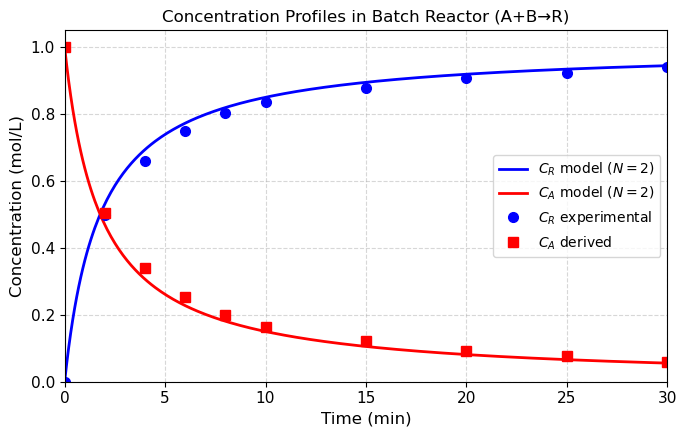

fig1 saved.


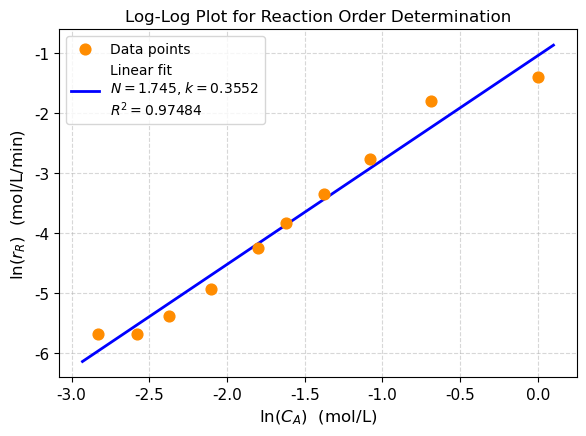

fig2 saved.


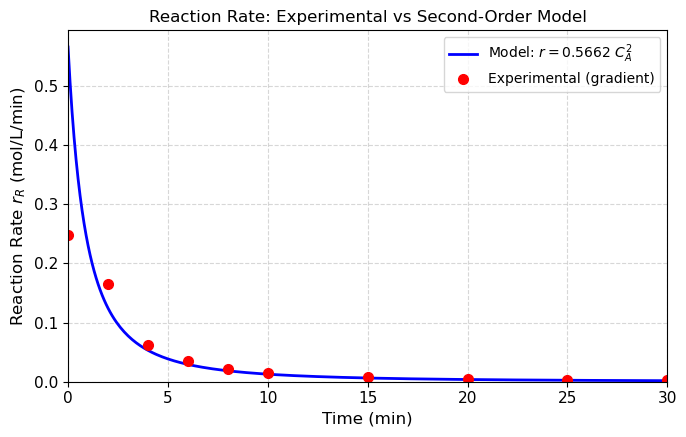

fig3 saved.

所有圖形已儲存至: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_03\figs


In [16]:
# ============================================================
# 結果圖形輸出
# ============================================================

# 平滑時間軸供繪製模型曲線
t_smooth = np.linspace(0, 30, 300)
C_A_smooth = C_A0 / (1 + C_A0 * k_int * t_smooth)   # 二階批次反應解析解
C_R_smooth = C_A0 - C_A_smooth

# ----------------------------------------------------------
# 圖1：濃度隨時間變化
# ----------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(t_smooth, C_R_smooth, 'b-',  lw=2, label=r'$C_R$ model ($N=2$)')
ax1.plot(t_smooth, C_A_smooth, 'r-',  lw=2, label=r'$C_A$ model ($N=2$)')
ax1.plot(t_exp, C_R_exp, 'bo', ms=7, label=r'$C_R$ experimental')
ax1.plot(t_exp, C_A_exp, 'rs', ms=7, label=r'$C_A$ derived')
ax1.set_xlabel('Time (min)', fontsize=12)
ax1.set_ylabel('Concentration (mol/L)', fontsize=12)
ax1.set_title('Concentration Profiles in Batch Reactor (A+B→R)', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_xlim(0, 30)
ax1.set_ylim(0, 1.05)
ax1.grid(True, ls='--', alpha=0.5)
fig1.tight_layout()
fig1.savefig(os.path.join(FIG_DIR, 'fig1_concentration.png'), dpi=150)
plt.show()
print("fig1 saved.")

# ----------------------------------------------------------
# 圖2：ln-ln 迴歸圖
# ----------------------------------------------------------
ln_CA_line = np.linspace(ln_CA.min() - 0.1, ln_CA.max() + 0.1, 100)
ln_r_line  = slope * ln_CA_line + intercept

fig2, ax2 = plt.subplots(figsize=(6, 4.5))
ax2.scatter(ln_CA, ln_r, color='darkorange', s=60, zorder=5, label='Data points')
ax2.plot(ln_CA_line, ln_r_line, 'b-', lw=2,
         label=f'Linear fit\n$N={N_stats:.3f}$, $k={k_stats:.4f}$\n$R^2={R2:.5f}$')
ax2.set_xlabel(r'$\ln(C_A)$  (mol/L)', fontsize=12)
ax2.set_ylabel(r'$\ln(r_R)$  (mol/L/min)', fontsize=12)
ax2.set_title('Log-Log Plot for Reaction Order Determination', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, ls='--', alpha=0.5)
fig2.tight_layout()
fig2.savefig(os.path.join(FIG_DIR, 'fig2_loglog_regression.png'), dpi=150)
plt.show()
print("fig2 saved.")

# ----------------------------------------------------------
# 圖3：反應速率比較（實驗 vs 二階模型）
# ----------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(7, 4.5))
ax3.plot(t_smooth, k_int * (C_A_smooth**N_int), 'b-', lw=2,
         label=f'Model: $r = {k_int:.4f}\\ C_A^{{{N_int}}}$')
ax3.plot(t_exp[mask], r_exp[mask], 'ro', ms=7, label='Experimental (gradient)')
ax3.set_xlabel('Time (min)', fontsize=12)
ax3.set_ylabel('Reaction Rate $r_R$ (mol/L/min)', fontsize=12)
ax3.set_title('Reaction Rate: Experimental vs Second-Order Model', fontsize=12)
ax3.legend(fontsize=10)
ax3.set_xlim(0, 30)
ax3.set_ylim(bottom=0)
ax3.grid(True, ls='--', alpha=0.5)
fig3.tight_layout()
fig3.savefig(os.path.join(FIG_DIR, 'fig3_rate_comparison.png'), dpi=150)
plt.show()
print("fig3 saved.")

print("\n所有圖形已儲存至:", FIG_DIR)